# Día 4 — Notebook de Demostración del Agente Multi-Paso

**Grupo 5 — Agente multi-paso (MedSAM + CNN + Gemini)**  
**Proyecto**: Clasificación de posicionamiento de dedo en escáner biométrico  
**Fecha**: Mayo 2026

---

## Objetivo

Este notebook es la **demostración presentable** del agente. Muestra el pipeline completo paso a paso sobre dos imágenes reales:

- **Demo 1**: imagen donde la CNN tiene alta confianza → el agente decide sin Gemini
- **Demo 2**: imagen donde la CNN es incierta → Gemini actúa como árbitro

Cada paso del pipeline se visualiza con la imagen intermedia resultante.

---

## 0. Carga de modelos

Misma configuración que los notebooks de Día 2 y Día 3.

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import numpy as np
from PIL import Image
from io import BytesIO
import base64
import os
import json
import random
from pathlib import Path
from dotenv import find_dotenv, load_dotenv
from openai import OpenAI
from segment_anything import sam_model_registry, SamPredictor
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")

PyTorch : 2.11.0+cu130
CUDA    : False


In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Encontrar la raíz del proyecto buscando .git hacia arriba (funciona
# independientemente de desde dónde se lance Jupyter)
def _find_project_root():
    current = Path(os.getcwd()).resolve()
    for p in [current] + list(current.parents):
        if (p / ".git").exists():
            return p
    return current

PROJECT_ROOT = _find_project_root()
MEDSAM_CKPT  = PROJECT_ROOT / "MedSAM_GeminiAPI/Dia1/medsam_vit_b.pth"
CNN_CKPT     = PROJECT_ROOT / "CNN_desde_0/modelosEntrenados/best_ResidualCNN.pth"
DATASET_DIR  = PROJECT_ROOT / "CNN_desde_0/imagenes_procesadas"
GEMINI_MODEL = "google/gemini-2.0-flash-lite-001"

UMBRAL_CNN    = 0.70   # Día 1: p_cnn < 0.70 → Gemini arbitra
UMBRAL_MEDSAM = 0.60   # Día 1: score < 0.60 → error, imagen no válida

IDX_TO_LABEL = {0: "no", 1: "si"}   # igual que en CNN_Main_Final.ipynb

CNN_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print("\nVerificando rutas...")
for nombre, ruta in [("MedSAM checkpoint", MEDSAM_CKPT),
                     ("ResidualCNN pesos",  CNN_CKPT),
                     ("Dataset",            DATASET_DIR)]:
    ok = "✓" if ruta.exists() else "✗  FALTA"
    print(f"  {ok}  {nombre}: {ruta}")

print(f"\nDevice        : {DEVICE}")
print(f"Umbral CNN    : {UMBRAL_CNN}")
print(f"Umbral MedSAM : {UMBRAL_MEDSAM}")

Raíz del proyecto: /home/carlos/Escritorio/Carlos/Prog/Programacio/ProyectoFinal_CSEBDIA

Verificando rutas...
  ✓  MedSAM checkpoint: /home/carlos/Escritorio/Carlos/Prog/Programacio/ProyectoFinal_CSEBDIA/MedSAM_GeminiAPI/Dia1/medsam_vit_b.pth
  ✓  ResidualCNN pesos: /home/carlos/Escritorio/Carlos/Prog/Programacio/ProyectoFinal_CSEBDIA/CNN_desde_0/modelosEntrenados/best_ResidualCNN.pth
  ✓  Dataset: /home/carlos/Escritorio/Carlos/Prog/Programacio/ProyectoFinal_CSEBDIA/CNN_desde_0/imagenes_procesadas

Device        : cpu
Umbral CNN    : 0.7
Umbral MedSAM : 0.6


In [3]:
raw = torch.load(MEDSAM_CKPT, map_location=DEVICE)
sam = sam_model_registry["vit_b"](checkpoint=None)
state = raw.get("model", raw) if isinstance(raw, dict) else raw
if isinstance(state, dict):
    missing, unexpected = sam.load_state_dict(state, strict=False)
    if missing:
        print(f"  Claves faltantes: {len(missing)}")

sam.to(DEVICE).eval()
predictor = SamPredictor(sam)
n_params = sum(p.numel() for p in sam.parameters())
print(f"✓ MedSAM (ViT-B) cargado — {n_params/1e6:.1f}M parámetros — device: {DEVICE}")

✓ MedSAM (ViT-B) cargado — 93.7M parámetros — device: cpu


In [4]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1      = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1        = nn.BatchNorm2d(out_channels)
        self.relu       = nn.ReLU(inplace=True)
        self.conv2      = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2        = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        return self.relu(out + identity)


class ResidualCNN(nn.Module):
    def __init__(self, in_channels=3, num_classes=2):
        super().__init__()
        self.conv1  = nn.Sequential(
            nn.Conv2d(in_channels, 32, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        self.layer1 = self._make_layer(32,  64,  2)
        self.layer2 = self._make_layer(64,  128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def _make_layer(self, in_ch, out_ch, blocks, stride=1):
        down = None
        if stride != 1 or in_ch != out_ch:
            down = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
        layers = [ResidualBlock(in_ch, out_ch, stride, down)]
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_ch, out_ch))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        return self.fc(x)


model_cnn = ResidualCNN(in_channels=3, num_classes=2).to(DEVICE)
model_cnn.load_state_dict(torch.load(CNN_CKPT, map_location=DEVICE))
model_cnn.eval()
n = sum(p.numel() for p in model_cnn.parameters())
print(f"✓ ResidualCNN cargada — {n:,} parámetros — device: {DEVICE}")

✓ ResidualCNN cargada — 2,795,170 parámetros — device: cpu


In [5]:
load_dotenv(find_dotenv())
OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY")
if not OPENROUTER_API_KEY:
    raise ValueError("No se encontró OPENROUTER_API_KEY en el .env")

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)

# Verificación rápida
resp = client.chat.completions.create(
    model=GEMINI_MODEL,
    messages=[{"role": "user", "content": "Responde solo 'OK'."}]
)
print(f"✓ Gemini conectado: {resp.choices[0].message.content.strip()}")

✓ Gemini conectado: OK


In [6]:
class AgenteMedico:
    """
    Agente multi-paso MedSAM → ResidualCNN → Gemini.
    Diseño del Día 1, implementación del Día 2 — Grupo 5, Proyecto IA RX.
    """
    UMBRAL_CNN    = UMBRAL_CNN
    UMBRAL_MEDSAM = UMBRAL_MEDSAM

    def __init__(self, predictor, cnn, gemini_client, device="cpu"):
        self.predictor = predictor
        self.cnn       = cnn
        self.client    = gemini_client
        self.device    = device

    # ── Paso 1: MedSAM ────────────────────────────────────────────────────────
    def segmentar(self, img_array):
        """
        Segmenta el dedo con MedSAM usando bounding box central (margen 10%).
        Condición de paso: score >= UMBRAL_MEDSAM (0.60).
        Devuelve (mask_bool_array, score_float).
        """
        h, w = img_array.shape[:2]
        m    = 0.10
        bbox = np.array([[int(w*m), int(h*m), int(w*(1-m)), int(h*(1-m))]])
        self.predictor.set_image(img_array)
        masks, scores, _ = self.predictor.predict(box=bbox, multimask_output=True)
        idx   = int(np.argmax(scores))
        score = float(scores[idx])
        if score < self.UMBRAL_MEDSAM:
            raise ValueError(
                f"Segmentación insuficiente: score={score:.3f} < {self.UMBRAL_MEDSAM}"
            )
        return masks[idx], score

    # ── Paso 2: ResidualCNN ───────────────────────────────────────────────────
    def clasificar(self, img_array, mask):
        """
        Aplica la máscara MedSAM y clasifica con ResidualCNN.
        Condición de paso: p_cnn >= UMBRAL_CNN (0.70) → veredicto directo.
        Devuelve (clase_str, p_max) — clase_str es 'SI' o 'NO'.
        """
        img_masked = img_array.copy()
        img_masked[~mask] = 0                        # fuera de máscara → negro

        tensor = CNN_TRANSFORM(
            Image.fromarray(img_masked.astype(np.uint8))
        ).unsqueeze(0).to(self.device)

        with torch.no_grad():
            probs = torch.softmax(self.cnn(tensor), dim=1).squeeze().cpu().numpy()

        idx_pred = int(np.argmax(probs))
        clase    = IDX_TO_LABEL[idx_pred].upper()    # 'SI' o 'NO'
        return clase, float(probs[idx_pred])

    # ── Control: ¿necesita árbitro? ───────────────────────────────────────────
    def necesita_arbitraje(self, p_cnn):
        """
        True si la CNN es incierta (p_cnn < UMBRAL_CNN).
        False → veredicto directo de la CNN.
        """
        return p_cnn < self.UMBRAL_CNN

    # ── Paso 3: Gemini (condicional) ─────────────────────────────────────────
    def consultar_gemini(self, img_array, mask, pred_cnn, p_cnn):
        """
        Consulta a Gemini como árbitro multimodal.
        Recibe: imagen original + overlay MedSAM + predicción CNN + confianza.
        Devuelve: (clase_final_str, razon_str).
        """
        def _to_b64(arr):
            buf = BytesIO()
            pil = Image.fromarray(arr.astype(np.uint8))
            if pil.mode != "RGB":
                pil = pil.convert("RGB")
            pil.save(buf, format="JPEG", quality=85)
            return base64.b64encode(buf.getvalue()).decode()

        overlay         = img_array.copy()
        overlay[mask]   = [50, 220, 80]              # máscara en verde

        prompt = (
            "Eres un sistema experto en análisis de posicionamiento biométrico.\n"
            "Se te presentan dos imágenes de una radiografía térmica de un dedo sobre un escáner biométrico.\n\n"
            "IMAGEN 1: Fotografía original del dedo sobre el escáner.\n"
            "IMAGEN 2: Máscara de segmentación de MedSAM (región del dedo resaltada en verde).\n\n"
            f"El clasificador CNN predijo: [{pred_cnn}] con confianza [{p_cnn:.1%}].\n"
            "Esta confianza es BAJA (< 70%), necesitamos tu criterio.\n\n"
            "El escáner tiene una franja luminosa (zona brillante). El dedo entero debe quedar centrado\n"
            "encima de esa franja, sin desplazarse ni salirse. Ese es el único criterio.\n\n"
            "CORRECTO (SI):\n"
            "- El dedo está colocado encima de la franja luminosa y centrado en ella.\n"
            "- El dedo no se sale de la franja ni por los lados ni por arriba/abajo.\n"
            "- El dedo cubre la franja de forma plana, sin estar girado ni inclinado.\n\n"
            "INCORRECTO (NO):\n"
            "- El dedo está desplazado: parte del dedo queda fuera de la franja luminosa.\n"
            "- El dedo solo toca un extremo o un lado de la franja, no el centro.\n"
            "- El dedo está girado o inclinado de modo que no cubre bien la franja.\n\n"
            "Responde ÚNICAMENTE con este formato exacto:\n"
            "VEREDICTO: [SI / NO]\n"
            "RAZÓN: [Una sola frase con el criterio visual determinante]"
        )

        resp = self.client.chat.completions.create(
            model=GEMINI_MODEL,
            messages=[{"role": "user", "content": [
                {"type": "image_url",
                 "image_url": {"url": f"data:image/jpeg;base64,{_to_b64(img_array)}"}},
                {"type": "image_url",
                 "image_url": {"url": f"data:image/jpeg;base64,{_to_b64(overlay)}"}},
                {"type": "text", "text": prompt}
            ]}],
            temperature=0.1,
            max_tokens=200
        )

        raw = resp.choices[0].message.content.strip()
        clase_final, razon = "NO", raw

        for line in raw.splitlines():
            upper = line.upper()
            if upper.startswith("VEREDICTO:"):
                clase_final = "SI" if "SI" in upper else "NO"
            elif upper.startswith("RAZ"):
                razon = line.split(":", 1)[-1].strip()

        return clase_final, razon

    # ── Orquestador: pipeline completo ────────────────────────────────────────
    def veredicto_final(self, ruta_imagen):
        """
        Ejecuta el pipeline completo MedSAM → CNN → (Gemini si necesario).

        Devuelve dict con trazabilidad completa:
          imagen, error, score_medsam, clase_cnn, p_cnn,
          arbitraje_gemini, clase_final, razon_gemini
        """
        res = {
            "imagen"         : Path(ruta_imagen).name,
            "error"          : None,
            "score_medsam"   : None,
            "clase_cnn"      : None,
            "p_cnn"          : None,
            "arbitraje_gemini": False,
            "clase_final"    : None,
            "razon_gemini"   : None,
        }
        try:
            img = np.array(Image.open(ruta_imagen).convert("RGB"))

            # Paso 1
            mask, score = self.segmentar(img)
            res["score_medsam"] = round(score, 4)

            # Paso 2
            clase_cnn, p_cnn = self.clasificar(img, mask)
            res["clase_cnn"], res["p_cnn"] = clase_cnn, round(p_cnn, 4)

            # Paso 3 (condicional)
            if self.necesita_arbitraje(p_cnn):
                res["arbitraje_gemini"] = True
                clase_final, razon      = self.consultar_gemini(img, mask, clase_cnn, p_cnn)
                res["clase_final"]      = clase_final
                res["razon_gemini"]     = razon
            else:
                res["clase_final"] = clase_cnn

        except ValueError as e:
            res["error"] = str(e)

        return res

In [7]:
agente = AgenteMedico(
    predictor     = predictor,
    cnn           = model_cnn,
    gemini_client = client,
    device        = str(DEVICE)
)
print("✓ AgenteMedico listo")
print(f"  Umbral CNN    : {agente.UMBRAL_CNN}")
print(f"  Umbral MedSAM : {agente.UMBRAL_MEDSAM}")

✓ AgenteMedico listo
  Umbral CNN    : 0.7
  Umbral MedSAM : 0.6


---

## Diagrama de flujo del agente

Representación del pipeline completo antes de las demostraciones.

In [8]:
# Diagrama de flujo en texto — reproducible sin Mermaid
print("""
╔══════════════════════════════════════════════════════════════════╗
║           PIPELINE AGENTE MEDICO — GRUPO 5                      ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║   [Imagen PNG 640×480]                                          ║
║          │                                                       ║
║          ▼                                                       ║
║   ┌─────────────────────────────────────┐                       ║
║   │ PASO 1 — MedSAM (ViT-B)            │                       ║
║   │  Entrada: imagen RGB                │                       ║
║   │  Salida : máscara binaria + score   │                       ║
║   └─────────────────────────────────────┘                       ║
║          │                                                       ║
║    score >= 0.60?                                               ║
║      No  │  Sí                                                  ║
║     ─────┤                                                       ║
║    ERROR │                                                       ║
║          ▼                                                       ║
║   ┌─────────────────────────────────────┐                       ║
║   │ PASO 2 — ResidualCNN (2.8M params) │                       ║
║   │  Entrada: imagen con fondo negro    │                       ║
║   │  Salida : clase (SI/NO) + p_cnn    │                       ║
║   └─────────────────────────────────────┘                       ║
║          │                                                       ║
║    p_cnn >= 0.70?                                               ║
║      Sí  │  No                                                  ║
║    ──────┤  ────────────────────────────┐                       ║
║          │                              ▼                        ║
║          │          ┌──────────────────────────────────┐        ║
║          │          │ PASO 3 — Gemini 2.0 Flash Lite  │        ║
║          │          │  Entrada: img + overlay + CNN    │        ║
║          │          │  Salida : clase + razón texto    │        ║
║          │          └──────────────────────────────────┘        ║
║          │                              │                        ║
║          ▼                              ▼                        ║
║   [VEREDICTO CNN]              [VEREDICTO GEMINI]               ║
║   Alta confianza               + RAZÓN en texto                 ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")

print(f"Umbrales:")
print(f"  UMBRAL_MEDSAM = {UMBRAL_MEDSAM}  → segmentación mínima aceptable")
print(f"  UMBRAL_CNN    = {UMBRAL_CNN}  → por debajo, Gemini arbitra")
print(f"\nModelos:")
print(f"  MedSAM   : ViT-B, ~90M params — segment_anything")
print(f"  CNN      : ResidualCNN, 2.79M params — entrenada por Grupo 2")
print(f"  Gemini   : gemini-2.0-flash-lite-001 vía OpenRouter (zero-shot)")



╔══════════════════════════════════════════════════════════════════╗
║           PIPELINE AGENTE MEDICO — GRUPO 5                      ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║   [Imagen PNG 640×480]                                          ║
║          │                                                       ║
║          ▼                                                       ║
║   ┌─────────────────────────────────────┐                       ║
║   │ PASO 1 — MedSAM (ViT-B)            │                       ║
║   │  Entrada: imagen RGB                │                       ║
║   │  Salida : máscara binaria + score   │                       ║
║   └─────────────────────────────────────┘                       ║
║          │                                                       ║
║    score >= 0.60?                                               ║
║      No  │  Sí                          

---

## Selección de imágenes de demostración

Se busca automáticamente:
- La imagen con **mayor** `p_cnn` → CNN muy segura (Demo 1)
- La imagen con **menor** `p_cnn` → CNN muy insegura (Demo 2)

In [9]:
import random
random.seed(7)

test_si  = sorted((DATASET_DIR / "test" / "si").glob("*.png"))
test_no  = sorted((DATASET_DIR / "test" / "no").glob("*.png"))
all_imgs = [(p, "SI") for p in test_si] + [(p, "NO") for p in test_no]

# Evaluar CNN + verificar que MedSAM también pasa el umbral
model_cnn.eval()
candidatos = []
print("Evaluando candidatos (CNN + MedSAM)...")
for img_path, clase_real in all_imgs:
    # CNN confidence
    tensor = CNN_TRANSFORM(Image.open(img_path).convert("RGB")).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(model_cnn(tensor), dim=1).squeeze().cpu().numpy()
    p_cnn = float(probs.max())

    # MedSAM score — descartamos imágenes que no pasan el umbral
    img_arr = np.array(Image.open(img_path).convert("RGB"))
    h, w = img_arr.shape[:2]
    m = 0.10
    bbox = np.array([[int(w*m), int(h*m), int(w*(1-m)), int(h*(1-m))]])
    agente.predictor.set_image(img_arr)
    _, scores_sam, _ = agente.predictor.predict(box=bbox, multimask_output=True)
    score_medsam = float(scores_sam.max())

    ok = score_medsam >= UMBRAL_MEDSAM
    print(f"  {img_path.name:28s} | p_cnn={p_cnn:.3f} | medsam={score_medsam:.3f} {'✓' if ok else '✗ SKIP'}")
    if ok:
        candidatos.append({"path": img_path, "clase_real": clase_real,
                            "p_cnn": p_cnn, "score_medsam": score_medsam})

candidatos.sort(key=lambda x: x["p_cnn"], reverse=True)

# Demo 1: mayor p_cnn con MedSAM OK → CNN decide directamente (p_cnn >= 0.70)
demo_alta = next((c for c in candidatos if c["p_cnn"] >= UMBRAL_CNN), candidatos[0])
# Demo 2: menor p_cnn con MedSAM OK → Gemini arbitra (p_cnn < 0.70)
demo_baja = next((c for c in reversed(candidatos) if c["p_cnn"] < UMBRAL_CNN), candidatos[-1])

print(f"\nDemo 1 (CNN decide):     {demo_alta['path'].name}  p_cnn={demo_alta['p_cnn']:.4f}  medsam={demo_alta['score_medsam']:.4f}  real={demo_alta['clase_real']}")
print(f"Demo 2 (Gemini arbitra): {demo_baja['path'].name}  p_cnn={demo_baja['p_cnn']:.4f}  medsam={demo_baja['score_medsam']:.4f}  real={demo_baja['clase_real']}")


Evaluando candidatos (CNN + MedSAM)...
  img_1776863513281.png        | p_cnn=0.548 | medsam=0.596 ✗ SKIP
  img_1776863889130.png        | p_cnn=0.507 | medsam=0.636 ✓
  img_1776863909985.png        | p_cnn=0.524 | medsam=0.628 ✓
  img_1777026517084.png        | p_cnn=0.501 | medsam=0.616 ✓
  img_1777026555963.png        | p_cnn=0.536 | medsam=0.599 ✗ SKIP
  img_1777027170211.png        | p_cnn=0.512 | medsam=0.615 ✓
  img_1777027595858.png        | p_cnn=0.533 | medsam=0.587 ✗ SKIP
  img_1777028264615.png        | p_cnn=0.500 | medsam=0.616 ✓
  img_1776864630193.png        | p_cnn=0.806 | medsam=0.590 ✗ SKIP
  img_1776864644631.png        | p_cnn=0.561 | medsam=0.615 ✓
  img_1777026670875.png        | p_cnn=0.516 | medsam=0.606 ✓
  img_1777027201011.png        | p_cnn=0.545 | medsam=0.586 ✗ SKIP
  img_1777027661410.png        | p_cnn=0.537 | medsam=0.611 ✓
  img_1777027673930.png        | p_cnn=0.531 | medsam=0.618 ✓
  img_1777028297087.png        | p_cnn=0.513 | medsam=0.595 ✗ SKIP
 

---

## Demo 1 — CNN decide directamente (`p_cnn ≥ 0.70`)

El agente ejecuta MedSAM (Paso 1) y la CNN (Paso 2). Como la confianza es alta, el veredicto es directamente el de la CNN — Gemini no interviene.

Se muestran los 5 pasos del pipeline en una sola fila:

| ① | ② | ③ | ④ | ⑤ |
|---|---|---|---|---|
| Imagen original | Máscara MedSAM | CNN input (fondo negro) | Probabilidades CNN | Veredicto final |

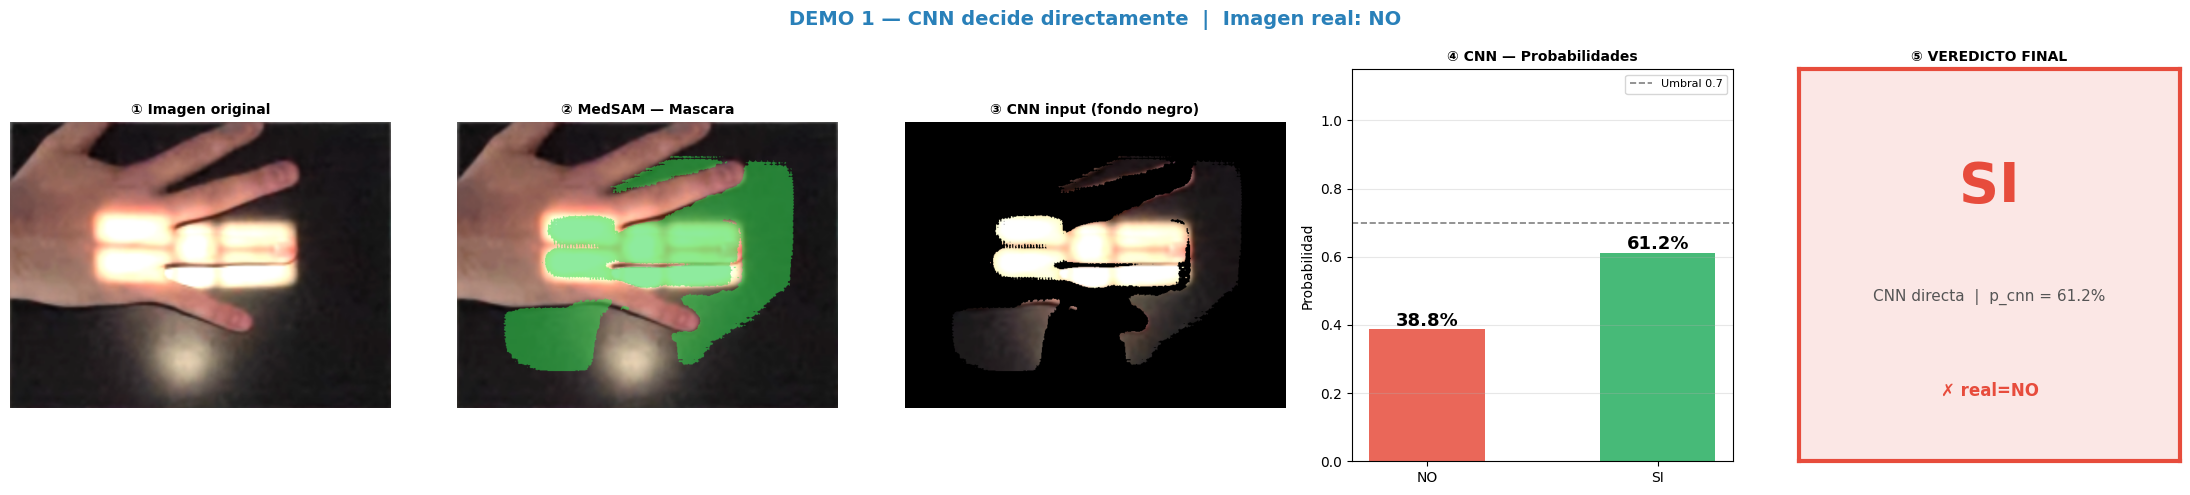

✓ DEMO 1 completada — CNN decide: SI (61.2%)


In [10]:
img_path = demo_alta["path"]
img      = np.array(Image.open(img_path).convert("RGB"))
clase_real = demo_alta["clase_real"]

# ── Paso 1: MedSAM ───────────────────────────────────────────────────────────
mask, score_sam = agente.segmentar(img)
sam_overlay     = img.copy()
sam_overlay[mask] = (0.45 * sam_overlay[mask] + 0.55 * np.array([50, 220, 80])).astype(np.uint8)

# ── Paso 2: CNN ───────────────────────────────────────────────────────────────
img_masked = img.copy(); img_masked[~mask] = 0
clase_cnn, p_cnn = agente.clasificar(img, mask)

tensor_vis = CNN_TRANSFORM(Image.fromarray(img_masked.astype(np.uint8))).unsqueeze(0).to(DEVICE)
with torch.no_grad():
    probs_all = torch.softmax(model_cnn(tensor_vis), dim=1).squeeze().cpu().numpy()

# ── Layout: 5 columnas ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle(f"DEMO 1 — CNN decide directamente  |  Imagen real: {clase_real}",
             fontsize=14, fontweight="bold", color="#2980b9")

titles = ["① Imagen original", "② MedSAM — Mascara", "③ CNN input (fondo negro)",
          "④ CNN — Probabilidades", "⑤ VEREDICTO FINAL"]

# ① Original
axes[0].imshow(img)
axes[0].set_title(titles[0], fontsize=10, fontweight="bold")
axes[0].axis("off")

# ② MedSAM overlay
axes[1].imshow(sam_overlay)
color_s = "#27ae60" if score_sam >= UMBRAL_MEDSAM else "#e74c3c"
axes[1].set_title(titles[1], fontsize=10, fontweight="bold")
axes[1].set_xlabel(f"Score MedSAM: {score_sam:.4f}", fontsize=10, color=color_s)
axes[1].axis("off")

# ③ Imagen enmascarada
axes[2].imshow(img_masked)
axes[2].set_title(titles[2], fontsize=10, fontweight="bold")
axes[2].axis("off")

# ④ Barras de probabilidad CNN
clases = ["NO", "SI"]
colores_barra = ["#e74c3c" if c == "NO" else "#27ae60" for c in clases]
bars = axes[3].bar(clases, probs_all[[0,1]], color=colores_barra, alpha=0.85, width=0.5)
for bar, val in zip(bars, probs_all[[0,1]]):
    axes[3].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f"{val:.1%}", ha="center", fontsize=13, fontweight="bold")
axes[3].axhline(UMBRAL_CNN, color="gray", linestyle="--", linewidth=1.2,
                label=f"Umbral {UMBRAL_CNN}")
axes[3].set_ylim(0, 1.15); axes[3].set_ylabel("Probabilidad")
axes[3].set_title(titles[3], fontsize=10, fontweight="bold")
axes[3].legend(fontsize=8); axes[3].grid(axis="y", alpha=0.3)

# ⑤ Veredicto final
acierto   = clase_cnn == clase_real
color_v   = "#27ae60" if acierto else "#e74c3c"
simbolo   = "✓" if acierto else "✗"
axes[4].set_facecolor(color_v + "22")
axes[4].text(0.5, 0.70, clase_cnn,    ha="center", va="center", fontsize=40,
             fontweight="bold", color=color_v, transform=axes[4].transAxes)
axes[4].text(0.5, 0.42, f"CNN directa  |  p_cnn = {p_cnn:.1%}", ha="center", va="center",
             fontsize=11, color="#555", transform=axes[4].transAxes)
axes[4].text(0.5, 0.18, f"{simbolo} real={clase_real}", ha="center", va="center",
             fontsize=12, fontweight="bold", color=color_v, transform=axes[4].transAxes)
for spine in axes[4].spines.values():
    spine.set_edgecolor(color_v); spine.set_linewidth(3)
axes[4].set_title(titles[4], fontsize=10, fontweight="bold")
axes[4].set_xticks([]); axes[4].set_yticks([])

plt.tight_layout()
plt.savefig("dia4_demo1_cnn_directa.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ DEMO 1 completada — CNN decide: {clase_cnn} ({p_cnn:.1%})")


---

## Demo 2 — Gemini arbitra (`p_cnn < 0.70`)

### Pasos 1 y 2: MedSAM + CNN incierta

La CNN produce una confianza baja — el agente detecta que no es suficientemente seguro y activa el árbitro Gemini.

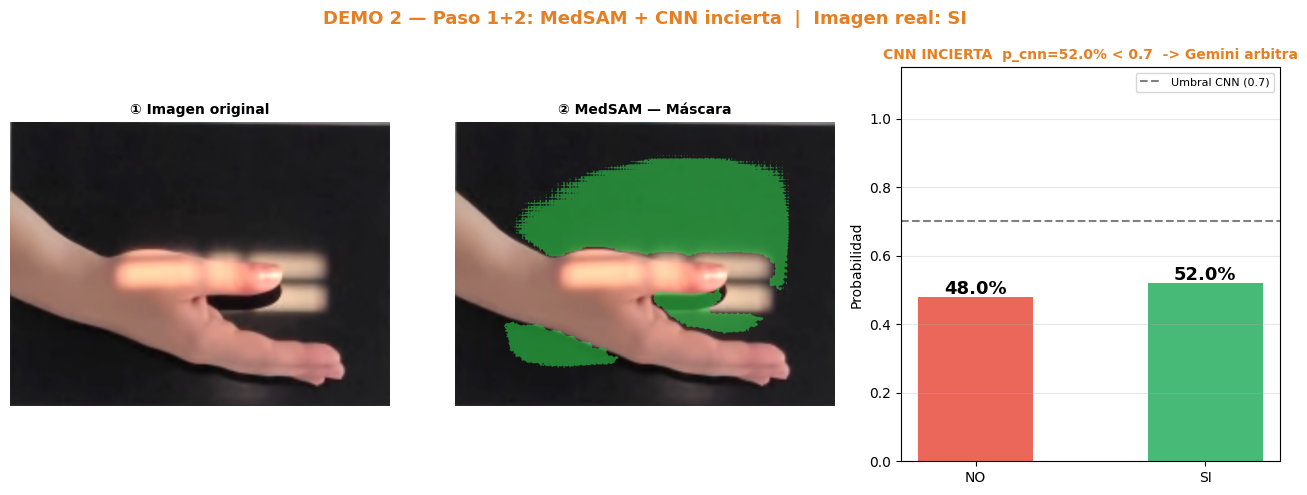

CNN incierta: SI con 52.0% → Se activa Gemini como árbitro


In [11]:
img_path_2 = demo_baja["path"]
img2       = np.array(Image.open(img_path_2).convert("RGB"))
clase_real2 = demo_baja["clase_real"]

# ── Paso 1: MedSAM ───────────────────────────────────────────────────────────
mask2, score_sam2 = agente.segmentar(img2)
sam_overlay2 = img2.copy()
sam_overlay2[mask2] = (0.45 * sam_overlay2[mask2] + 0.55 * np.array([50, 220, 80])).astype(np.uint8)

img_masked2 = img2.copy(); img_masked2[~mask2] = 0

# ── Paso 2: CNN ───────────────────────────────────────────────────────────────
clase_cnn2, p_cnn2 = agente.clasificar(img2, mask2)

tensor_vis2 = CNN_TRANSFORM(Image.fromarray(img_masked2.astype(np.uint8))).unsqueeze(0).to(DEVICE)
with torch.no_grad():
    probs_all2 = torch.softmax(model_cnn(tensor_vis2), dim=1).squeeze().cpu().numpy()

# ── Layout: 3 primeras columnas (mismo que demo 1) ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle(f"DEMO 2 — Paso 1+2: MedSAM + CNN incierta  |  Imagen real: {clase_real2}",
             fontsize=13, fontweight="bold", color="#e67e22")

axes[0].imshow(img2)
axes[0].set_title("① Imagen original", fontsize=10, fontweight="bold"); axes[0].axis("off")

color_s2 = "#27ae60" if score_sam2 >= UMBRAL_MEDSAM else "#e74c3c"
axes[1].imshow(sam_overlay2)
axes[1].set_title("② MedSAM — Máscara", fontsize=10, fontweight="bold")
axes[1].set_xlabel(f"Score MedSAM: {score_sam2:.4f}", fontsize=10, color=color_s2)
axes[1].axis("off")

clases = ["NO", "SI"]
colores_b = ["#e74c3c" if c == "NO" else "#27ae60" for c in clases]
bars2 = axes[2].bar(clases, probs_all2[[0,1]], color=colores_b, alpha=0.85, width=0.5)
for bar, val in zip(bars2, probs_all2[[0,1]]):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.01,
                 f"{val:.1%}", ha="center", fontsize=13, fontweight="bold")
axes[2].axhline(UMBRAL_CNN, color="gray", linestyle="--", linewidth=1.5,
                label=f"Umbral CNN ({UMBRAL_CNN})")
axes[2].set_ylim(0, 1.15); axes[2].set_ylabel("Probabilidad")
axes[2].set_title(f"CNN INCIERTA  p_cnn={p_cnn2:.1%} < {UMBRAL_CNN}  -> Gemini arbitra",
                  fontsize=10, fontweight="bold", color="#e67e22")
axes[2].legend(fontsize=8); axes[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("dia4_demo2_paso1y2.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"CNN incierta: {clase_cnn2} con {p_cnn2:.1%} → Se activa Gemini como árbitro")


### Paso 3: Gemini recibe dos imágenes y emite veredicto

Gemini recibe:
- **Imagen 1**: la fotografía original del dedo sobre el escáner
- **Imagen 2**: la misma imagen con la máscara MedSAM coloreada en verde

Gemini devuelve un veredicto (`SI`/`NO`) y una razón en texto.

Consultando a Gemini como árbitro...
  Gemini responde: NO
  Razón: El dedo está desplazado y parte de él queda fuera de la franja luminosa.


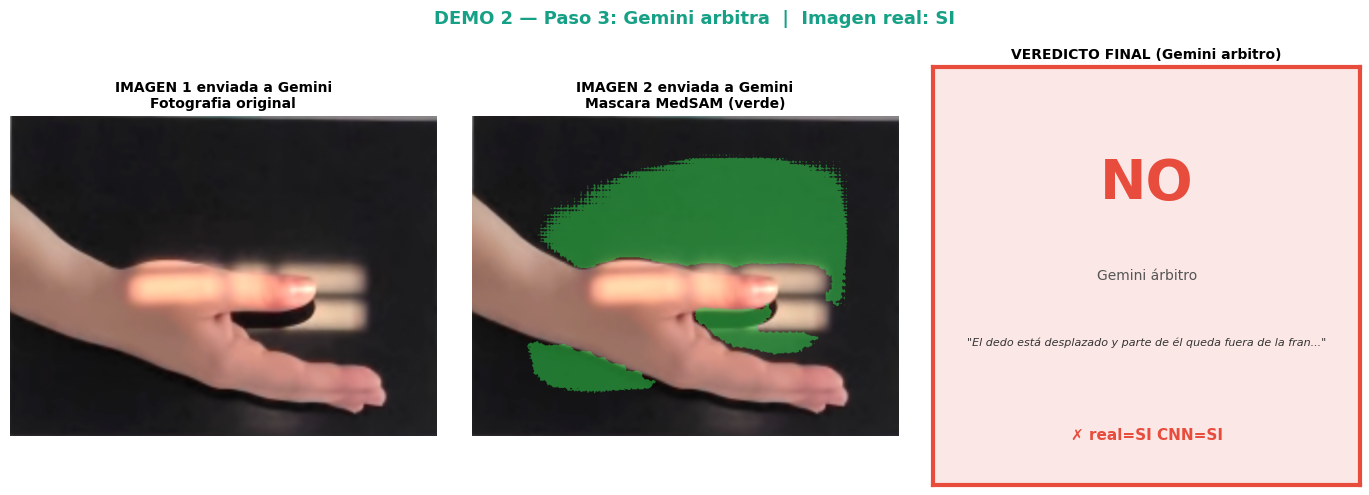


✓ DEMO 2 completada — Gemini decide: NO


In [12]:
# ── Paso 3: Gemini arbitra ────────────────────────────────────────────────────
print("Consultando a Gemini como árbitro...")
clase_final2, razon2 = agente.consultar_gemini(img2, mask2, clase_cnn2, p_cnn2)
print(f"  Gemini responde: {clase_final2}")
print(f"  Razón: {razon2}")

acierto2  = clase_final2 == clase_real2
color_v2  = "#27ae60" if acierto2 else "#e74c3c"
simbolo2  = "✓" if acierto2 else "✗"

# ── Layout: overlay Gemini + veredicto ───────────────────────────────────────
overlay2 = img2.copy()
overlay2[mask2] = (0.5 * overlay2[mask2] + 0.5 * np.array([50, 220, 80])).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle(f"DEMO 2 — Paso 3: Gemini arbitra  |  Imagen real: {clase_real2}",
             fontsize=13, fontweight="bold", color="#16a085")

# Imagen 1 enviada a Gemini
axes[0].imshow(img2)
axes[0].set_title("IMAGEN 1 enviada a Gemini\nFotografia original", fontsize=10, fontweight="bold")
axes[0].axis("off")

# Imagen 2 enviada a Gemini
axes[1].imshow(overlay2)
axes[1].set_title("IMAGEN 2 enviada a Gemini\nMascara MedSAM (verde)", fontsize=10, fontweight="bold")
axes[1].axis("off")

# Veredicto de Gemini
axes[2].set_facecolor(color_v2 + "22")
axes[2].text(0.5, 0.72, clase_final2, ha="center", va="center", fontsize=40,
             fontweight="bold", color=color_v2, transform=axes[2].transAxes)
axes[2].text(0.5, 0.50, "Gemini árbitro", ha="center", va="center",
             fontsize=10, color="#555", transform=axes[2].transAxes)

razon_wrap = razon2[:60] + ("..." if len(razon2) > 60 else "")
axes[2].text(0.5, 0.34, f'"{razon_wrap}"', ha="center", va="center",
             fontsize=8, color="#333", style="italic", wrap=True,
             transform=axes[2].transAxes)
axes[2].text(0.5, 0.12, f"{simbolo2} real={clase_real2} CNN={clase_cnn2}",
             ha="center", va="center", fontsize=11, fontweight="bold",
             color=color_v2, transform=axes[2].transAxes)
for spine in axes[2].spines.values():
    spine.set_edgecolor(color_v2); spine.set_linewidth(3)
axes[2].set_title("VEREDICTO FINAL (Gemini arbitro)", fontsize=10, fontweight="bold")
axes[2].set_xticks([]); axes[2].set_yticks([])

plt.tight_layout()
plt.savefig("dia4_demo2_gemini.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✓ DEMO 2 completada — Gemini decide: {clase_final2}")


---

## Pipeline completo — Ambas demos lado a lado

Visualización comparativa de las dos demos en el mismo grid:

- **Fila 1** (azul): CNN decide directamente
- **Fila 2** (verde oscuro): Gemini actúa como árbitro

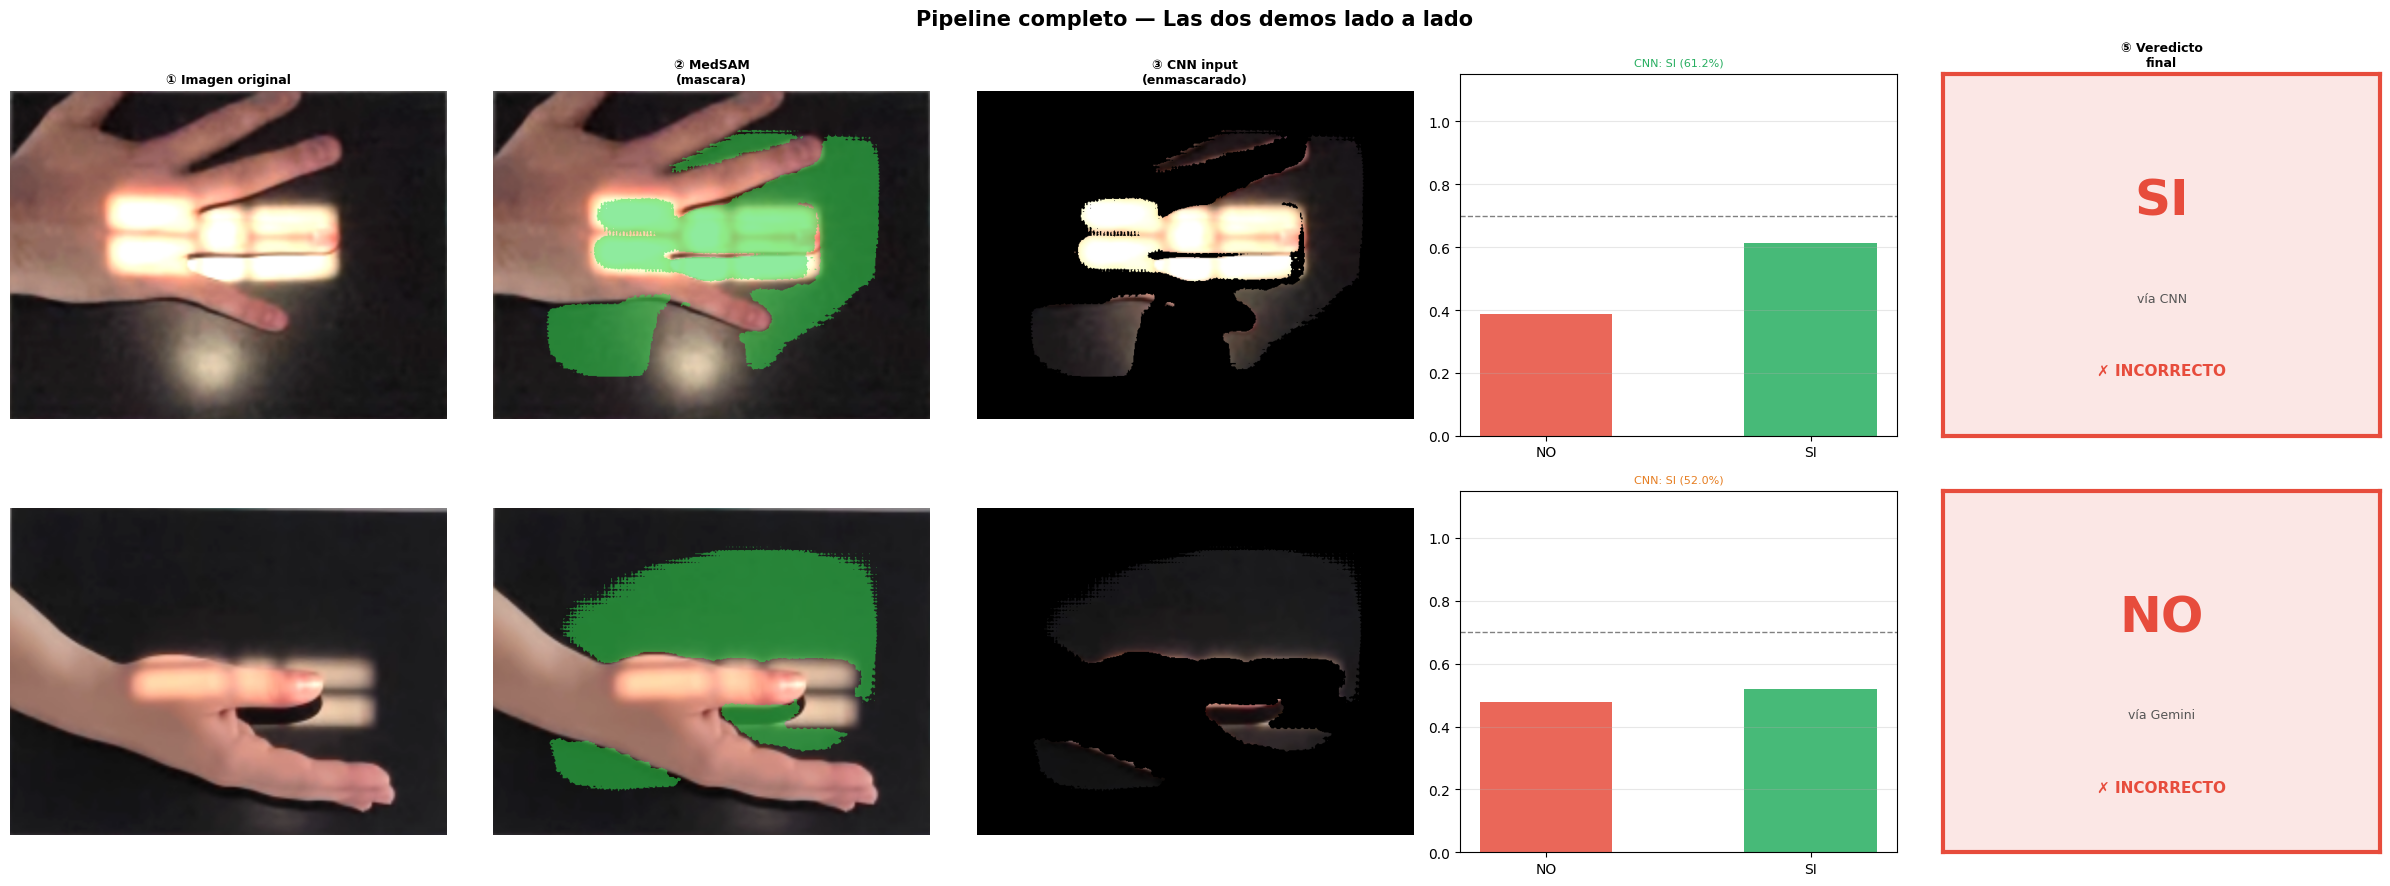

✓ dia4_pipeline_completo.png guardada


In [13]:
# Cuadro comparativo de las dos demos
fig, axes = plt.subplots(2, 5, figsize=(24, 9))
fig.suptitle("Pipeline completo — Las dos demos lado a lado", fontsize=15, fontweight="bold")

col_titles = ["① Imagen original", "② MedSAM\n(mascara)", "③ CNN input\n(enmascarado)",
              "④ CNN\nprobabilidades", "⑤ Veredicto\nfinal"]
for j, t in enumerate(col_titles):
    axes[0, j].set_title(t, fontsize=9, fontweight="bold", pad=6)

def fill_row(row, img, mask, img_masked, probs, clase_cnn, p_cnn, clase_final,
             clase_real, via_gemini, razon=None):
    color_row = "#2980b9" if not via_gemini else "#16a085"
    acierto   = clase_final == clase_real
    color_v   = "#27ae60" if acierto else "#e74c3c"

    ov = img.copy()
    ov[mask] = (0.45 * ov[mask] + 0.55 * np.array([50, 220, 80])).astype(np.uint8)

    axes[row, 0].imshow(img)
    _lbl = "Gemini arbitra" if via_gemini else "CNN directa"
    axes[row, 0].set_ylabel(
        f"Real: {clase_real}\n{_lbl}",
        fontsize=9, color=color_row, fontweight="bold"
    )
    axes[row, 0].axis("off")

    axes[row, 1].imshow(ov); axes[row, 1].axis("off")

    axes[row, 2].imshow(img_masked); axes[row, 2].axis("off")

    clases = ["NO", "SI"]
    colores_b = ["#e74c3c", "#27ae60"]
    axes[row, 3].bar(clases, probs[[0,1]], color=colores_b, alpha=0.85, width=0.5)
    axes[row, 3].axhline(UMBRAL_CNN, color="gray", linestyle="--", linewidth=1)
    axes[row, 3].set_ylim(0, 1.15)
    axes[row, 3].set_title(f"CNN: {clase_cnn} ({p_cnn:.1%})", fontsize=8,
                            color="#e67e22" if via_gemini else "#27ae60")
    axes[row, 3].grid(axis="y", alpha=0.3)

    axes[row, 4].set_facecolor(color_v + "22")
    axes[row, 4].text(0.5, 0.65, clase_final, ha="center", va="center",
                      fontsize=36, fontweight="bold", color=color_v,
                      transform=axes[row, 4].transAxes)
    via_txt = "vía Gemini" if via_gemini else "vía CNN"
    axes[row, 4].text(0.5, 0.38, via_txt, ha="center", va="center",
                      fontsize=9, color="#555", transform=axes[row, 4].transAxes)
    simbolo = "✓ CORRECTO" if acierto else "✗ INCORRECTO"
    axes[row, 4].text(0.5, 0.18, simbolo, ha="center", va="center",
                      fontsize=11, fontweight="bold", color=color_v,
                      transform=axes[row, 4].transAxes)
    for spine in axes[row, 4].spines.values():
        spine.set_edgecolor(color_v); spine.set_linewidth(3)
    axes[row, 4].set_xticks([]); axes[row, 4].set_yticks([])

fill_row(0, img, mask, img_masked, probs_all, clase_cnn, p_cnn,
         clase_cnn, clase_real, via_gemini=False)
fill_row(1, img2, mask2, img_masked2, probs_all2, clase_cnn2, p_cnn2,
         clase_final2, clase_real2, via_gemini=True, razon=razon2)

plt.tight_layout()
plt.savefig("dia4_pipeline_completo.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ dia4_pipeline_completo.png guardada")


---

## Resumen

| Demo | Modelo que decide | Confianza CNN | Veredicto | Correcto |
|------|------------------|---------------|-----------|----------|
| Demo 1 | CNN directa | Alta (≥ 0.70) | clase_cnn | ver resultado |
| Demo 2 | Gemini árbitro | Baja (< 0.70) | clase_gemini + razón | ver resultado |

### Cuándo interviene Gemini

Gemini **no interviene siempre** — solo en los casos donde la CNN duda. Esto reduce el coste de API y la latencia en la mayoría de imágenes. El umbral 0.70 se eligió porque Gemini (70% accuracy zero-shot) es mejor árbitro que la CNN (60% accuracy) en los casos inciertos.

---

*Demostración del Día 4 — Grupo 5 — Proyecto IA RX — Mayo 2026*